In [19]:
import pandas as pd

df = pd.read_csv("../data/interim/packets.csv")

print("Loaded rows:", len(df))
df.head()

Loaded rows: 41848


,timestamp_raw,timestamp_display,ip_version,src_ip,dst_ip,src_port,dst_port,protocol,packet_length,tcp_flags,is_broadcast,is_multicast,highest_layer
0,1.741991e+09,44.4002,4,192.168.0.16,224.0.0.251,5353.0,5353.0,UDP,319,NaN,False,True,DNS
1,1.741991e+09,44.4002,6,fe80::e62:a6ff:fea2:46ca,ff02::fb,5353.0,5353.0,UDP,339,NaN,False,True,DNS
2,1.741991e+09,44.4002,6,::,ff02::1:ffab:cdee,NaN,NaN,OTHER,64,NaN,False,True,ICMPv6 Neighbor Discovery - Neighbor Solicitation
3,1.741991e+09,44.4002,6,2600:8800:b400:2b00:211:22ff:feab:cdee,ff02::1,NaN,NaN,OTHER,72,NaN,False,True,ICMPv6 Neighbor Discovery Option - Destination...
4,1.741991e+09,44.4002,6,fe80::98bf:b2ff:fe49:808a,ff02::16,NaN,NaN,OTHER,76,NaN,False,True,MLDv2 - Multicast Listener Report


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41848 entries, 0 to 41847
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp_raw      41848 non-null  float64
 1   timestamp_display  41848 non-null  float64
 2   ip_version         41848 non-null  int64  
 3   src_ip             41848 non-null  str    
 4   dst_ip             41848 non-null  str    
 5   src_port           29973 non-null  float64
 6   dst_port           29973 non-null  float64
 7   protocol           41848 non-null  str    
 8   packet_length      41848 non-null  int64  
 9   tcp_flags          5396 non-null   str    
 10  is_broadcast       41848 non-null  bool   
 11  is_multicast       41848 non-null  bool   
 12  highest_layer      41848 non-null  str    
dtypes: bool(2), float64(4), int64(2), str(5)
memory usage: 3.6 MB


In [21]:
df.isna().sum()

timestamp_raw            0
timestamp_display        0
ip_version               0
src_ip                   0
dst_ip                   0
src_port             11875
dst_port             11875
protocol                 0
packet_length            0
tcp_flags            36452
is_broadcast             0
is_multicast             0
highest_layer            0
dtype: int64

In [22]:
df["protocol"].value_counts()

protocol
UDP      24577
OTHER    11875
TCP       5396
Name: count, dtype: int64

In [23]:
df["dst_port"].value_counts().head(10)

dst_port
5353.0     17108
443.0       2718
58065.0     1532
43117.0     1459
37152.0     1416
10001.0     1328
1900.0      1027
46692.0      476
9999.0       326
60524.0      315
Name: count, dtype: int64

In [24]:
df["packet_length"].describe()

count    41848.000000
mean       283.294829
std        308.940026
min         32.000000
25%         76.000000
50%        110.000000
75%        398.000000
max       1500.000000
Name: packet_length, dtype: float64

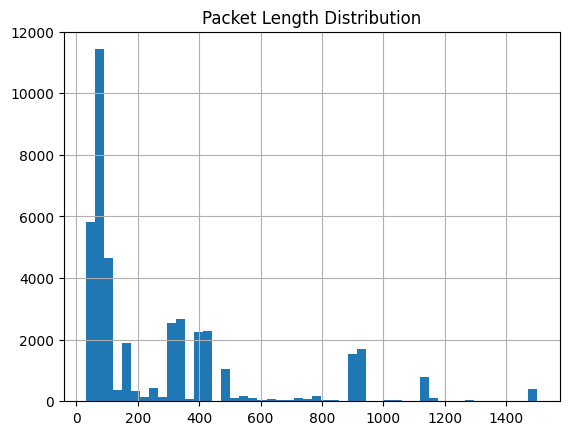

In [25]:
import matplotlib.pyplot as plt

df["packet_length"].hist(bins=50)
plt.title("Packet Length Distribution")
plt.show()

In [8]:
print("Unique src IPs:", df["src_ip"].nunique())
print("Unique dst IPs:", df["dst_ip"].nunique())

Unique src IPs: 75
Unique dst IPs: 69


In [9]:
df[["src_ip", "dst_ip", "protocol", "dst_port"]].head(20)

,src_ip,dst_ip,protocol,dst_port
0,192.168.0.16,224.0.0.251,UDP,5353.0
1,NaN,NaN,UDP,5353.0
2,NaN,NaN,OTHER,NaN
3,NaN,NaN,OTHER,NaN
4,NaN,NaN,OTHER,NaN
5,NaN,NaN,OTHER,NaN
6,NaN,NaN,OTHER,NaN
7,192.168.0.16,224.0.0.251,UDP,5353.0
8,NaN,NaN,UDP,5353.0
9,192.168.0.34,224.0.0.251,UDP,5353.0


In [10]:
## Dropping MAC address columns as that layer was stripped
df = df.drop(columns=["src_mac", "dst_mac"], errors="ignore")

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41848 entries, 0 to 41847
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      41848 non-null  float64
 1   src_ip         22379 non-null  str    
 2   dst_ip         22379 non-null  str    
 3   src_port       29973 non-null  float64
 4   dst_port       29973 non-null  float64
 5   protocol       41848 non-null  str    
 6   packet_length  41848 non-null  int64  
 7   tcp_flags      5396 non-null   str    
 8   is_broadcast   41848 non-null  bool   
 9   is_multicast   41848 non-null  bool   
 10  highest_layer  41848 non-null  str    
dtypes: bool(2), float64(3), int64(1), str(5)
memory usage: 3.0 MB


In [12]:
## post clean_packets script
df_clean = pd.read_csv("../data/interim/packets_clean.csv")

print("Rows:", len(df_clean))
df_clean.head()

Rows: 7401


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,packet_length,tcp_flags,is_broadcast,is_multicast,highest_layer
0,58.8475,192.168.0.22,192.168.0.255,47424,32761,UDP,116,NONE,False,False,Raw
1,62.8455,192.168.0.22,192.168.0.255,47424,32761,UDP,116,NONE,False,False,Raw
2,62.8535,192.168.0.22,192.168.0.255,47424,32761,UDP,116,NONE,False,False,Raw
3,21.0305,192.168.0.38,192.168.0.255,57621,57621,UDP,72,NONE,False,False,Raw
4,34.2051,192.168.0.232,192.168.0.255,57621,57621,UDP,72,NONE,False,False,Raw


In [13]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7401 entries, 0 to 7400
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      7401 non-null   float64
 1   src_ip         7401 non-null   str    
 2   dst_ip         7401 non-null   str    
 3   src_port       7401 non-null   int64  
 4   dst_port       7401 non-null   int64  
 5   protocol       7401 non-null   str    
 6   packet_length  7401 non-null   int64  
 7   tcp_flags      7401 non-null   str    
 8   is_broadcast   7401 non-null   bool   
 9   is_multicast   7401 non-null   bool   
 10  highest_layer  7401 non-null   str    
dtypes: bool(2), float64(1), int64(3), str(5)
memory usage: 535.0 KB


In [14]:
df_raw = pd.read_csv("../data/interim/packets.csv")
df_clean = pd.read_csv("../data/interim/packets_clean.csv")

print("Raw rows:", len(df_raw))
print("Clean rows:", len(df_clean))
print("Percent kept:", len(df_clean) / len(df_raw))

Raw rows: 41848
Clean rows: 7401
Percent kept: 0.17685432995603134


In [15]:
df_raw["protocol"].value_counts()

protocol
UDP      24577
OTHER    11875
TCP       5396
Name: count, dtype: int64

In [17]:
df_clean["protocol"].value_counts()

protocol
UDP      3730
TCP      3595
OTHER      76
Name: count, dtype: int64

In [ ]:
import pandas as pd

df_clean = pd.read_csv("../data/interim/packets_clean.csv")
print(df_clean.info())
print(df_clean["protocol"].value_counts())
print(df_clean[["src_ip", "dst_ip", "protocol", "dst_port"]].head(10))